In [3]:
# 1. Imports
import os
import zipfile
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split 
import matplotlib.pyplot as plt



In [5]:
# 2. Unzip data if not already extracted (assuming animaldata.zip is in current directory)
data_zip = 'animaldata.zip'
data_dir = './animaldata'

if not os.path.exists(data_dir):
    with zipfile.ZipFile(data_zip, 'r') as zip_ref:
        zip_ref.extractall(data_dir)




In [13]:
# 3. Data transforms for images (resize + normalize)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # mean RGB (ImageNet stats)
                         [0.229, 0.224, 0.225])  # std RGB
])


In [15]:
# 4. Load dataset
dataset = datasets.ImageFolder(root='./animaldata/data', transform=transform)

print("Classes found:", dataset.classes)  # should output ['cat', 'dog', 'snake'] or similar



Classes found: ['cats', 'dogs', 'snakes']


In [17]:
# Split dataset 80% train, 20% val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])



In [19]:
# Create loaders
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)



In [21]:
# Define model
class AnimalCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self._to_linear = None
        self._get_flattened_size()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._to_linear, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def _get_flattened_size(self):
        with torch.no_grad():
            x = torch.zeros(1, 3, 128, 128)
            x = self.features(x)
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Initialize model with correct num_classes
model = AnimalCNN(num_classes=len(dataset.classes)).to(device)

Device: cpu


In [23]:
# 6. Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [31]:
# 7. Training loop
epochs = 7
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []


for epoch in range(epochs):
    # Training phase
    model.train()
    running_loss, running_corrects = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_corrects += (preds == labels).sum().item()

    epoch_loss = running_loss / train_size
    epoch_acc = running_corrects / train_size
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Validation phase
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_corrects += (preds == labels).sum().item()

    val_epoch_loss = val_loss / val_size
    val_epoch_acc = val_corrects / val_size
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} | "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")



Epoch 1/7: Train Loss: 0.8358, Train Acc: 0.6075 | Val Loss: 0.8371, Val Acc: 0.5567
Epoch 2/7: Train Loss: 0.7853, Train Acc: 0.6438 | Val Loss: 0.7596, Val Acc: 0.6250
Epoch 3/7: Train Loss: 0.7356, Train Acc: 0.6596 | Val Loss: 0.7191, Val Acc: 0.6683
Epoch 4/7: Train Loss: 0.6799, Train Acc: 0.6908 | Val Loss: 0.7077, Val Acc: 0.6883
Epoch 5/7: Train Loss: 0.6298, Train Acc: 0.7200 | Val Loss: 0.6947, Val Acc: 0.6883
Epoch 6/7: Train Loss: 0.5713, Train Acc: 0.7562 | Val Loss: 0.7179, Val Acc: 0.6833
Epoch 7/7: Train Loss: 0.5034, Train Acc: 0.7942 | Val Loss: 0.7069, Val Acc: 0.6883


✅ Accuracy graph successfully saved as accuracy_graph.jpg
✅ Loss graph successfully saved as loss_graph.jpg


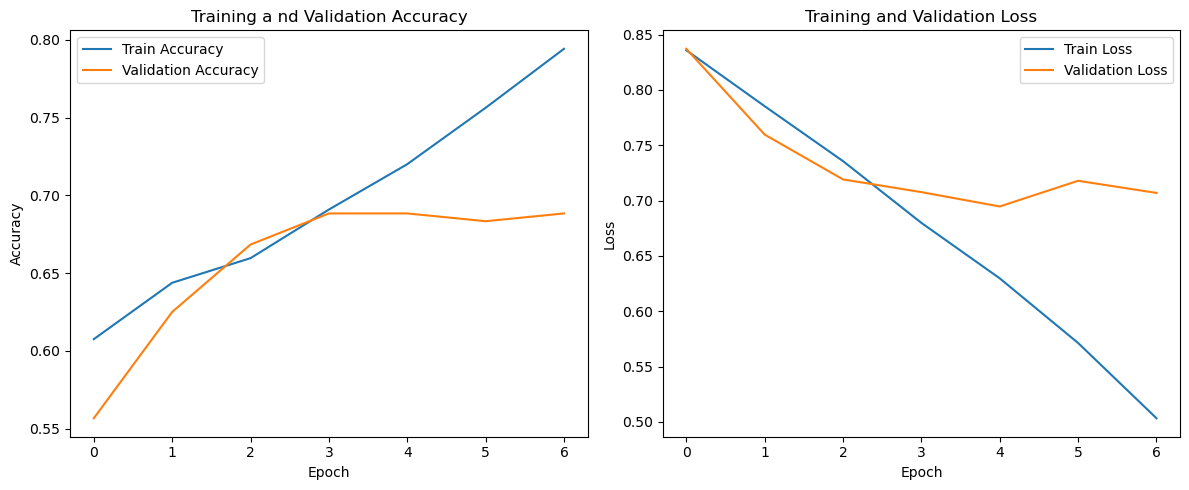

✓ Model saved successfully to: C:\Users\ashan\animal_model.pth
File size: 33936149 bytes
Final Validation Accuracy: 68.83%


In [35]:
# 8. Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training a nd Validation Accuracy')
plt.savefig("accuracy_graph.jpg", format='jpg', dpi=300)
print("✅ Accuracy graph successfully saved as accuracy_graph.jpg")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.savefig("loss_graph.jpg", format='jpg', dpi=300)
print("✅ Loss graph successfully saved as loss_graph.jpg")
plt.legend()

plt.tight_layout()
plt.show()

import os

# Save the model
save_path = r"C:\Users\ashan\animal_model.pth"
torch.save(model.state_dict(), save_path)

# Verify it was saved
if os.path.exists(save_path):
    print(f"✓ Model saved successfully to: {save_path}")
    print(f"File size: {os.path.getsize(save_path)} bytes")
else:
    print("✗ Error: Model was not saved!")
# 10. Final validation accuracy
print(f"Final Validation Accuracy: {val_accuracies[-1]*100:.2f}%")


In [68]:
import torch
from torchvision import transforms
from PIL import Image
import os

# Define your model class (should be the same as training)
class AnimalCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self._to_linear = None
        self._get_flattened_size()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._to_linear, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def _get_flattened_size(self):
        with torch.no_grad():
            x = torch.zeros(1, 3, 128, 128)
            x = self.features(x)
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the saved model and set it to evaluation mode
num_classes = len(dataset.classes)   # Replace with your actual number of classes
model = AnimalCNN(num_classes)
model.load_state_dict(torch.load('animal_model.pth', map_location=device))
model.to(device)
model.eval()

# Class names (replace or load according to your dataset)
class_names = ['cat', 'dog', 'snake']  # Use the actual class names from your dataset

# Image preprocessing (same as training)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0)  # Add batch dimension
    image = image.to(device)

    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs.data, 1)
        class_idx = predicted.item()
    return class_names[class_idx]

# For single image
image_path = r'C:\Users\ashan\Downloads\dog1.jpg'
predicted_class = predict_image(image_path)
print(f"Predicted class for the single image: {predicted_class}")

# For multiple images
image_folder = r'D:\MY-project\CNN\TestImage'
for img_file in os.listdir(image_folder):
    img_path = os.path.join(image_folder, img_file)
    if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
        pred = predict_image(img_path)
        print(f"{img_file}: {pred}")


Predicted class for the single image: dog
cat1.jpg: cat
dog.jpg: dog
snake.jpg: snake
